# HR PEOPLE ANALYTICS — Partie 1 : Chargement & EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# ── Style global ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#a0a0b0",
    "ytick.color":      "#a0a0b0",
    "text.color":       "#e0e0e0",
    "grid.color":       "#2a2d3d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "font.family":      "DejaVu Sans",
})
PALETTE   = ["#4f8ef7", "#d26946", "#4ff7a0", "#f7d44f", "#c44ff7"]
ACCENT    = "#4f8ef7"
WARN      = "#f7794f"


## Chargement et nettoyage des datasets

### Chargement

In [3]:
print("Chargement des datasets...")

employee   = pd.read_csv("employee_data.csv")
engagement = pd.read_csv("employee_engagement_survey_data.csv")
recruitment= pd.read_csv("recruitment_data.csv")
training   = pd.read_csv("training_and_development_data.csv")

print(f"  Employee       : {employee.shape}")
print(f"  Engagement     : {engagement.shape}")
print(f"  Recruitment    : {recruitment.shape}")
print(f"  Training       : {training.shape}")

Chargement des datasets...
  Employee       : (3000, 26)
  Engagement     : (3000, 5)
  Recruitment    : (3000, 18)
  Training       : (3000, 9)


### Affichage des informations globales

In [14]:
for df in [employee, engagement, recruitment, training]:
    print(df.info())
    print("\n" + "-"*50 + "\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   EmpID                       3000 non-null   int64 
 1   FirstName                   3000 non-null   object
 2   LastName                    3000 non-null   object
 3   StartDate                   3000 non-null   object
 4   ExitDate                    1533 non-null   object
 5   Title                       3000 non-null   object
 6   Supervisor                  3000 non-null   object
 7   ADEmail                     3000 non-null   object
 8   BusinessUnit                3000 non-null   object
 9   EmployeeStatus              3000 non-null   object
 10  EmployeeType                3000 non-null   object
 11  PayZone                     3000 non-null   object
 12  EmployeeClassificationType  3000 non-null   object
 13  TerminationType             3000 non-null   obje

### Nettoyage

In [15]:
print("\nNettoyage des données...")

# Harmonisation des clés de jointure
engagement.rename(columns={"Employee ID": "EmpID"}, inplace=True)
training.rename(columns={"Employee ID": "EmpID"}, inplace=True)

# Gestion des dates
date_cols_emp = ["StartDate", "ExitDate", "DOB"]
for col in date_cols_emp:
    employee[col] = pd.to_datetime(employee[col], dayfirst=True, errors="coerce")

engagement["Survey Date"] = pd.to_datetime(engagement["Survey Date"], dayfirst=True, errors="coerce")
training["Training Date"]  = pd.to_datetime(training["Training Date"],  dayfirst=True, errors="coerce")
recruitment["Application Date"] = pd.to_datetime(recruitment["Application Date"], errors="coerce")

# Calcul de l'âge et de l'ancienneté
today = pd.Timestamp.today()
employee["Age"] = ((today - employee["DOB"]).dt.days / 365.25).round(1)
employee["Seniority"] = ((today - employee["StartDate"]).dt.days / 365.25).round(1)

# Nettoyage des colonnes texte
employee["GenderCode"] = employee["GenderCode"].str.strip().str.title()
employee["RaceDesc"] = employee["RaceDesc"].str.strip().str.title()
employee["PayZone"] = employee["PayZone"].str.strip().str.upper()
employee["Performance Score"] = employee["Performance Score"].str.strip()

# Valeurs manquantes : rapport
missing = employee.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Colonnes avec valeurs manquantes :\n{missing.to_string()}\n")

# Suppression des doublons
for name, df in [("employee", employee), ("engagement", engagement),
                 ("training", training), ("recruitment", recruitment)]:
    dups = df.duplicated().sum()
    if dups:
        print(f"{dups} doublons trouvés dans {name} → supprimés")
    df.drop_duplicates(inplace=True)


Nettoyage des données...
Colonnes avec valeurs manquantes :
ExitDate                  1467
TerminationDescription    1467



## Jointure des tables

In [ ]:
print("Jointure des datasets...")

# Agrégation engagement par employé (moyenne sur toutes les enquêtes (surveys))
eng_agg = engagement.groupby("EmpID").agg(
    Engagement_Score    = ("Engagement Score", "mean"),
    Satisfaction_Score  = ("Satisfaction Score", "mean"),
    WorkLife_Score      = ("Work-Life Balance Score", "mean"),
    Survey_Count        = ("Engagement Score", "count")
).reset_index()

# Agrégation training par employé
train_agg = training.groupby("EmpID").agg(
    Training_Count    = ("Training Program Name", "count"),
    Training_Pass_Rate= ("Training Outcome", lambda x: (x == "Passed").mean()),
    Total_Training_Cost=("Training Cost", "sum"),
    Avg_Training_Days = ("Training Duration(Days)", "mean")
).reset_index()

# Master dataset
master = employee.merge(eng_agg, on="EmpID", how="left") \
                 .merge(train_agg, on="EmpID", how="left")

print(f"Master dataset: {master.shape[0]} lignes × {master.shape[1]} colonnes\n")

Jointure des datasets...
Master dataset: 3000 lignes × 36 colonnes



## EDA - VISUALISATIONS

Génération des visualisations EDA...


Text(0.5, 0.98, 'HR People Analytics — Exploration des Données')

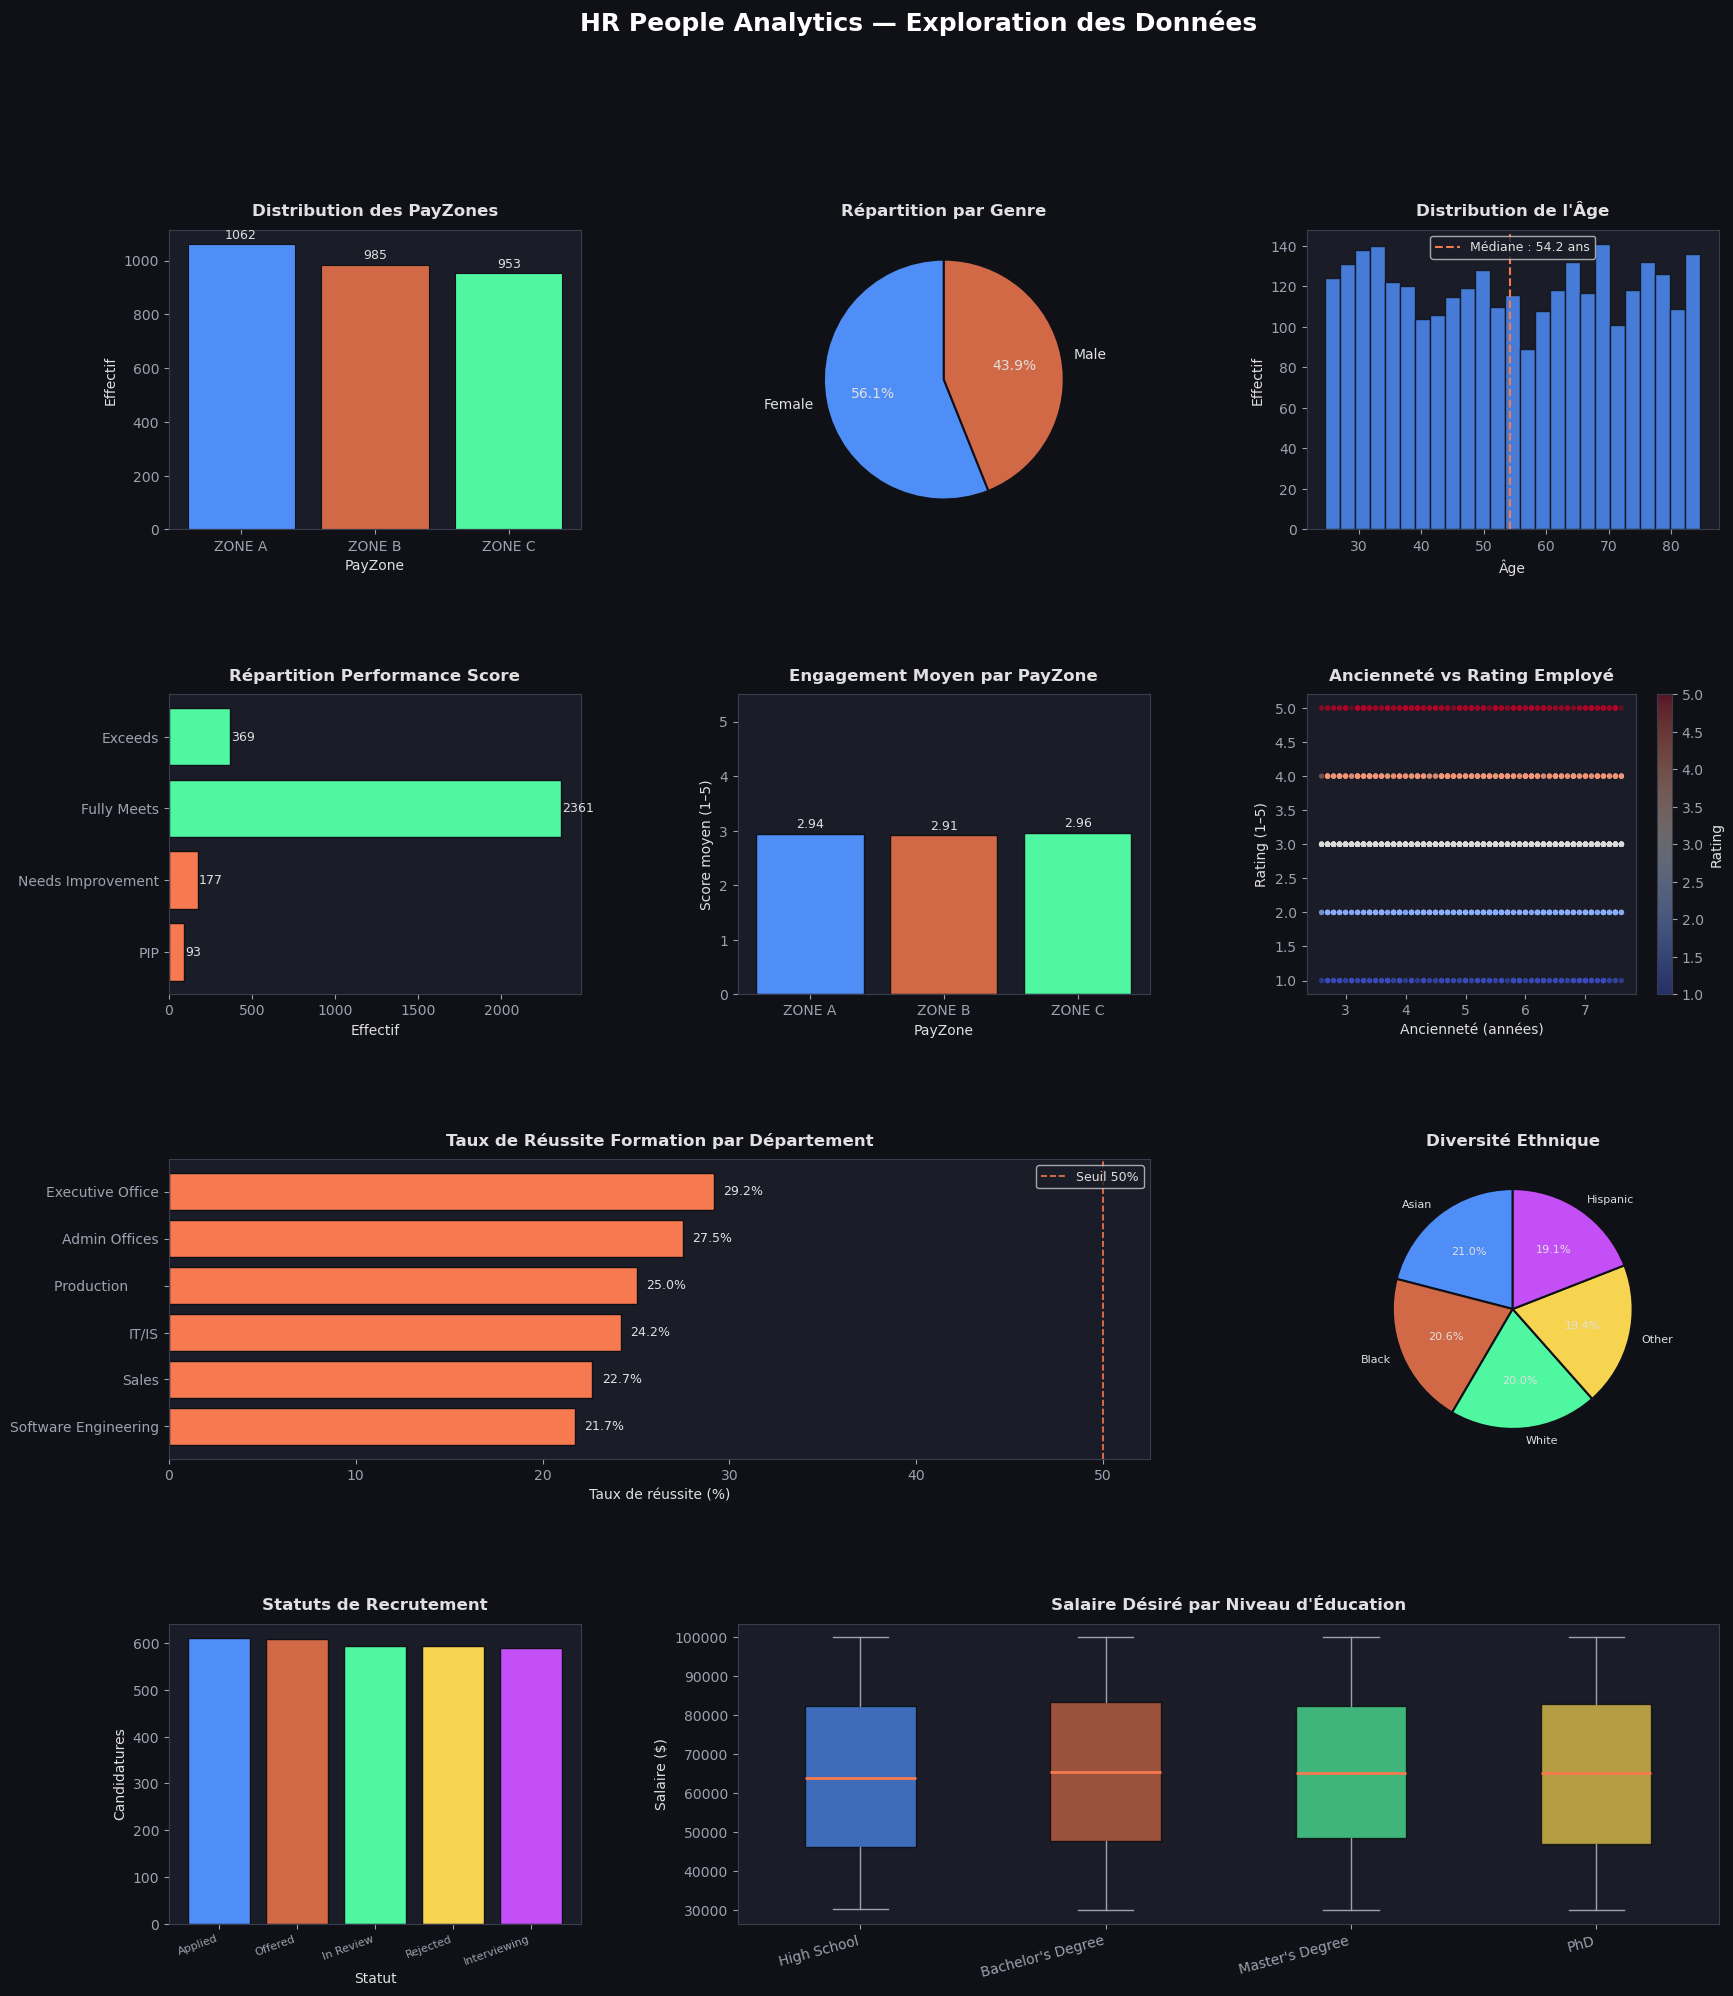

In [ ]:
print("Génération des visualisations EDA...")

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38)

# 4.1 Distribution des PayZones
ax1 = fig.add_subplot(gs[0, 0])
pz  = master["PayZone"].value_counts().sort_index()
bars = ax1.bar(pz.index, pz.values, color=PALETTE[:len(pz)], edgecolor="#0f1117", linewidth=0.8)
ax1.set_title("Distribution des PayZones", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("PayZone"); ax1.set_ylabel("Effectif")
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"{int(bar.get_height())}", ha="center", va="bottom", fontsize=9)

# 4.2 Répartition par genre
ax2  = fig.add_subplot(gs[0, 1])
gender_counts = master["GenderCode"].value_counts()
wedges, texts, autotexts = ax2.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=PALETTE,
    startangle=90,
    wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5)
)
for t in texts + autotexts:
    t.set_color("#e0e0e0")
ax2.set_title("Répartition par Genre", fontsize=12, fontweight="bold", pad=10)

# 4.3 Distribution de l'âge 
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(master["Age"].dropna(), bins=25, color=ACCENT, edgecolor="#0f1117", alpha=0.85)
ax3.axvline(master["Age"].median(), color=WARN, linestyle="--", linewidth=1.5,
            label=f"Médiane : {master['Age'].median():.1f} ans")
ax3.set_title("Distribution de l'Âge", fontsize=12, fontweight="bold", pad=10)
ax3.set_xlabel("Âge"); ax3.set_ylabel("Effectif")
ax3.legend(fontsize=9)

# 4.4 Performance Score 
ax4 = fig.add_subplot(gs[1, 0])
perf_order = ["PIP", "Needs Improvement", "Fully Meets", "Exceeds"]
perf_order  = [p for p in perf_order if p in master["Performance Score"].values]
perf_counts = master["Performance Score"].value_counts().reindex(perf_order).dropna()
colors_perf = [WARN if p in ["PIP","Needs Improvement"] else "#4ff7a0" for p in perf_counts.index]
bars4 = ax4.barh(perf_counts.index, perf_counts.values, color=colors_perf, edgecolor="#0f1117")
ax4.set_title("Répartition Performance Score", fontsize=12, fontweight="bold", pad=10)
ax4.set_xlabel("Effectif")
for bar in bars4:
    ax4.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f"{int(bar.get_width())}", va="center", fontsize=9)

# 4.5 Engagement moyen par PayZone
ax5 = fig.add_subplot(gs[1, 1])
eng_pz = master.groupby("PayZone")["Engagement_Score"].mean().sort_index()
bars5  = ax5.bar(eng_pz.index, eng_pz.values, color=PALETTE[:len(eng_pz)], edgecolor="#0f1117")
ax5.set_title("Engagement Moyen par PayZone", fontsize=12, fontweight="bold", pad=10)
ax5.set_xlabel("PayZone"); ax5.set_ylabel("Score moyen (1–5)")
ax5.set_ylim(0, 5.5)
for bar in bars5:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

# 4.6 Ancienneté & Current Employee Rating
ax6 = fig.add_subplot(gs[1, 2])
sc  = ax6.scatter(
    master["Seniority"].clip(0, 20),
    master["Current Employee Rating"],
    c=master["Current Employee Rating"],
    cmap="coolwarm", alpha=0.4, s=15, linewidths=0
)
plt.colorbar(sc, ax=ax6, label="Rating")
ax6.set_title("Ancienneté vs Rating Employé", fontsize=12, fontweight="bold", pad=10)
ax6.set_xlabel("Ancienneté (années)"); ax6.set_ylabel("Rating (1–5)")

# 4.7 Taux de réussite formation par département 
ax7 = fig.add_subplot(gs[2, :2])
train_dept = master.dropna(subset=["Training_Pass_Rate"]) \
                   .groupby("DepartmentType")["Training_Pass_Rate"].mean().sort_values()
colors7 = [WARN if v < 0.5 else ACCENT for v in train_dept.values]
bars7   = ax7.barh(train_dept.index, train_dept.values * 100, color=colors7, edgecolor="#0f1117")
ax7.axvline(50, color=WARN, linestyle="--", linewidth=1.2, label="Seuil 50%")
ax7.set_title("Taux de Réussite Formation par Département", fontsize=12, fontweight="bold", pad=10)
ax7.set_xlabel("Taux de réussite (%)")
for bar in bars7:
    ax7.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.1f}%", va="center", fontsize=9)
ax7.legend(fontsize=9)

# 4.8 Distribution raciale 
ax8 = fig.add_subplot(gs[2, 2])
race_counts = master["RaceDesc"].value_counts()
ax8.pie(race_counts.values, labels=race_counts.index, autopct="%1.1f%%",
        colors=PALETTE + ["#a0a0b0"], startangle=90,
        wedgeprops=dict(edgecolor="#0f1117", linewidth=1.5))
for t in ax8.texts:
    t.set_color("#e0e0e0"); t.set_fontsize(8)
ax8.set_title("Diversité Ethnique", fontsize=12, fontweight="bold", pad=10)

# 4.9 Statut de recrutement 
ax9 = fig.add_subplot(gs[3, 0])
status_counts = recruitment["Status"].value_counts()
bars9 = ax9.bar(status_counts.index, status_counts.values,
                color=PALETTE[:len(status_counts)], edgecolor="#0f1117")
ax9.set_title("Statuts de Recrutement", fontsize=12, fontweight="bold", pad=10)
ax9.set_xlabel("Statut"); ax9.set_ylabel("Candidatures")
plt.setp(ax9.get_xticklabels(), rotation=20, ha="right", fontsize=8)

# 4.10 Salaire désiré par niveau d'éducation
ax10 = fig.add_subplot(gs[3, 1:])
edu_order = ["High School", "Bachelor's Degree", "Master's Degree", "PhD"]
edu_order  = [e for e in edu_order if e in recruitment["Education Level"].values]
bp_data    = [recruitment[recruitment["Education Level"] == e]["Desired Salary"].dropna()
              for e in edu_order]
bp = ax10.boxplot(bp_data, labels=edu_order, patch_artist=True,
                  medianprops=dict(color=WARN, linewidth=2),
                  whiskerprops=dict(color="#a0a0b0"),
                  capprops=dict(color="#a0a0b0"),
                  flierprops=dict(marker="o", color=WARN, alpha=0.3, markersize=3))
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax10.set_title("Salaire Désiré par Niveau d'Éducation", fontsize=12, fontweight="bold", pad=10)
ax10.set_ylabel("Salaire ($)")
plt.setp(ax10.get_xticklabels(), rotation=15, ha="right")

# Titre principal
fig.suptitle("HR People Analytics — Exploration des Données",
             fontsize=18, fontweight="bold", color="white", y=0.98)

## Export du dataset final

In [31]:
master.to_csv("master_hr_dataset.csv", index=False)
print(f"\n Master dataset exporté : master_hr_dataset.csv ({master.shape[0]} lignes × {master.shape[1]} colonnes)")
print("\n Aperçu des colonnes du master dataset :")
print(master.dtypes.to_string())


 Master dataset exporté : master_hr_dataset.csv (3000 lignes × 36 colonnes)

 Aperçu des colonnes du master dataset :
EmpID                                  int64
FirstName                             object
LastName                              object
StartDate                     datetime64[ns]
ExitDate                      datetime64[ns]
Title                                 object
Supervisor                            object
ADEmail                               object
BusinessUnit                          object
EmployeeStatus                        object
EmployeeType                          object
PayZone                               object
EmployeeClassificationType            object
TerminationType                       object
TerminationDescription                object
DepartmentType                        object
Division                              object
DOB                           datetime64[ns]
State                                 object
JobFunctionDescription    